In [1]:
# ! pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

import seaborn as sns


In [3]:
df = pd.read_csv("G:\Omkar\DS_DA\ML\DataSets\Data Science Job Postings with Salaries (2025)\data_science_job_posts_2025.csv")

In [4]:
# EDA

In [5]:
df.info

<bound method DataFrame.info of                      job_title seniority_level   status      company  \
0               data scientist          senior   hybrid  company_003   
1               data scientist            lead   hybrid  company_005   
2               data scientist          senior  on-site  company_007   
3               data scientist          senior   hybrid  company_008   
4               data scientist             NaN  on-site  company_009   
..                         ...             ...      ...          ...   
939             data scientist          senior      NaN  company_171   
940  machine learning engineer          senior      NaN  company_134   
941             data scientist        midlevel  on-site  company_395   
942             data scientist        midlevel  on-site  company_395   
943             data scientist          senior  on-site  company_844   

                                              location    post_date  \
0                               

In [6]:
display(df)

,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
0,data scientist,senior,hybrid,company_003,"Grapevine, TX . Hybrid",17 days ago,"Bentonville, AR, US",Retail,Public,€352.44B,Public,"€100,472 - €200,938","['spark', 'r', 'python', 'scala', 'machine lea..."
1,data scientist,lead,hybrid,company_005,"Fort Worth, TX . Hybrid",15 days ago,"Detroit, MI, US",Manufacturing,Public,"155,030",€51.10B,"€118,733","['spark', 'r', 'python', 'sql', 'machine learn..."
2,data scientist,senior,on-site,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",a month ago,"Redwood City, CA, US",Technology,Public,"25,930",€33.80B,"€94,987 - €159,559","['aws', 'git', 'python', 'docker', 'sql', 'mac..."
3,data scientist,senior,hybrid,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",8 days ago,"San Jose, CA, US",Technology,Public,"34,690",€81.71B,"€112,797 - €194,402","['sql', 'r', 'python']"
4,data scientist,NaN,on-site,company_009,On-site,3 days ago,"Stamford, CT, US",Finance,Private,"1,800",Private,"€114,172 - €228,337",[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,data scientist,senior,NaN,company_171,"Bengaluru, Karnataka, India",a day ago,"Armonk, NY, US",Technology,Public,"524,598",€120.29B,"€33,288 - €53,080","['pytorch', 'python', 'sql', 'machine learning..."
940,machine learning engineer,senior,NaN,company_134,"Melbourne, Victoria, Australia",a month ago,"Seattle, WA, US",Retail,Public,"865,456",€838.78B,"€64,290","['amazon', 'machine learning']"
941,data scientist,midlevel,on-site,company_395,"McLean, VA",11 days ago,"McLean, VA, US",Retail,Public,"55,150",€36.29B,"€145,904 - €166,510","['spark', 'aws', 'r', 'python', 'scala', 'sql'..."
942,data scientist,midlevel,on-site,company_395,"New York, NY",17 days ago,"McLean, VA, US",Retail,Public,"55,110",€36.34B,"€159,149 - €181,595","['spark', 'aws', 'r', 'python', 'scala', 'sql'..."


In [7]:
# Code to check for null values in every column
null_counts = df.isnull().sum()
print(null_counts)


job_title            3
seniority_level     60
status             256
company              0
location             2
post_date            0
headquarter          0
industry             0
ownership           47
company_size         0
revenue             15
salary               0
skills               0
dtype: int64


In [8]:
# 3. Exploratory Data Analysis (EDA)
# Checking structure, missing values, and get an initial sense of your data distribution for key categorical columns.

print(df.info())                                # Checks data types and non-null counts
print(df.head())                                # Shows first five rows
print(df.isnull().sum())                        # Checks count of nulls per column
print(df.describe())                            # Summary stats for numeric columns
print(df['seniority_level'].value_counts())     # Frequency of seniority levels
print(df['location'].value_counts())            # Frequency of locations


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_title        941 non-null    object
 1   seniority_level  884 non-null    object
 2   status           688 non-null    object
 3   company          944 non-null    object
 4   location         942 non-null    object
 5   post_date        944 non-null    object
 6   headquarter      944 non-null    object
 7   industry         944 non-null    object
 8   ownership        897 non-null    object
 9   company_size     944 non-null    object
 10  revenue          929 non-null    object
 11  salary           944 non-null    object
 12  skills           944 non-null    object
dtypes: object(13)
memory usage: 96.0+ KB
None
        job_title seniority_level   status      company  \
0  data scientist          senior   hybrid  company_003   
1  data scientist            lead   hybrid  company_005

In [9]:
# 4. Cleaning and converting salary column.

def euro_salary_to_number(s):
    if pd.isna(s):
        return None
    s_clean = re.sub(r'[€,]', '', str(s))
    parts = re.split(r'\\s*-\\s*', s_clean)
    nums = [float(p.strip()) for p in parts if p.strip().replace('.', '', 1).isdigit()]
    if not nums:
        return None
    return sum(nums) / len(nums)

df['salary_numeric'] = df['salary'].apply(euro_salary_to_number)
df['salary_numeric'] = pd.to_numeric(df['salary_numeric'], errors='coerce')
print(df['salary_numeric'].head(10))
print(df['salary_numeric'].describe())




0         NaN
1    118733.0
2         NaN
3         NaN
4         NaN
5         NaN
6         NaN
7         NaN
8    207331.0
9    219201.0
Name: salary_numeric, dtype: float64
count    3.500000e+02
mean     1.103504e+05
std      1.971561e+05
min      7.678000e+03
25%      3.395525e+04
50%      8.450850e+04
75%      1.386240e+05
max      2.739979e+06
Name: salary_numeric, dtype: float64


In [10]:
# 5. Value counts for key categorical columns. Making sure that the columns are float type.
# For categorical data, seeing how frequently each label appears helps spot dominant categories, rare cases, or data entry issues.


print("Seniority Level Counts:\n", df['seniority_level'].value_counts())
print("Status Counts:\n", df['status'].value_counts())
print("Location Counts:\n", df['location'].value_counts())
print("Company Size Counts:\n", df['company_size'].value_counts())



Seniority Level Counts:
 seniority_level
senior      630
lead        116
midlevel    113
junior       25
Name: count, dtype: int64
Status Counts:
 status
on-site    363
hybrid     207
remote     118
Name: count, dtype: int64
Location Counts:
 location
Bengaluru, Karnataka, India                                      52
Fully Remote                                                     35
New York, NY                                                     22
United States                                                    22
On-site                                                          18
                                                                 ..
Camden, NJ                                                        1
Bellevue, WA . Austin, TX . Nashville, TN . Tempe, AZ             1
Bellevue, WA . Hybrid                                             1
New York, NY . New York, New York, Statele Unite Ale Americii     1
Plano, TX . Plano, Texas, Spojené státy . On-site                 1


In [11]:
# 6. Printing the categories of the data used.

print(df['salary_numeric'].head(10))
print(df['salary_numeric'].describe())
print(df['salary_numeric'].dropna().shape)


0         NaN
1    118733.0
2         NaN
3         NaN
4         NaN
5         NaN
6         NaN
7         NaN
8    207331.0
9    219201.0
Name: salary_numeric, dtype: float64
count    3.500000e+02
mean     1.103504e+05
std      1.971561e+05
min      7.678000e+03
25%      3.395525e+04
50%      8.450850e+04
75%      1.386240e+05
max      2.739979e+06
Name: salary_numeric, dtype: float64
(350,)


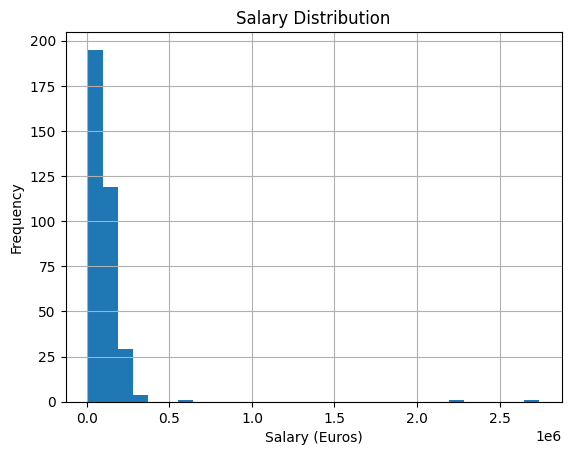

In [12]:
# 7. Salary Distribution Histogram. Plotting graphs.


df['salary_numeric'].dropna().hist(bins=30)
plt.title('Salary Distribution')
plt.xlabel('Salary (Euros)')
plt.ylabel('Frequency')
plt.show()




In [13]:
# 8. Handling the Nulls in Other Columns.
# Filling the missing values and prepping the data for ML so that it's not giving errors.
# Categorical Nulls are shown as 'Unknown' and Numerical Nulls are filled with Median values.

# a. Example: fill missing categories with 'Unknown'.

df['seniority_level'].fillna('Unknown', inplace=True)
df['location'].fillna('Unknown', inplace=True)



# b. Numerical: fill revenue with median (or 0).
# df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
# df['revenue'].fillna(df['revenue'].median(), inplace=True)


C:\Users\shree\AppData\Local\Temp\ipykernel_7480\3457187433.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['seniority_level'].fillna('Unknown', inplace=True)
C:\Users\shree\AppData\Local\Temp\ipykernel_7480\3457187433.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

In [14]:
# 8. Align Features and Target with a Common Mask.

mask = (
    df['salary_numeric'].notnull() &
    df['seniority_level'].notnull() &
    df['location'].notnull()
)
features_clean = df.loc[mask, ['seniority_level', 'location']]
salary_clean = df.loc[mask, 'salary_numeric']

In [15]:
# 9. Preparing Features for Modeling. Encoding.
# Using OneHotEncoding to convert categorical data into numerical data.

# features = df[['seniority_level', 'location']]
X = pd.get_dummies(features_clean)
y = salary_clean
print(X.shape, y.shape)

(350, 205) (350,)


In [16]:
# 10. Using only those rows with valid salary for training and testing.

mask = y.notnull()
X = X[mask]
y = y[mask]


In [17]:
# 11. Splitting data into training and testing.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [18]:
# 12. Training Model.

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
# 13. Predicting values.

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print('Root Mean Squared Error:', rmse)
print('Mean Squared Error:', mse)
print(y_pred)

Root Mean Squared Error: 58615.20772911288
Mean Squared Error: 3435742577.127054
[131252.62461103  68974.8187066  133896.02906965 131252.62461103
 121272.51172602 147931.05644251 200933.         121272.51172602
 151551.11288501 101163.30393047  85014.40445862  29395.40445861
 121272.51172602 131252.62461103 131252.62461103 194249.51966253
 133896.02906965  68974.8187066  131252.62461103 194249.51966253
 131252.62461103 101163.30393047 131252.62461103  91967.4843115
 131252.62461103  26752.         162123.5         58994.70582159
 121272.51172602 132831.704295    68974.8187066  133896.02906965
 121572.46413611  68974.8187066   68974.8187066  133896.02906965
  61775.         112599.31796715  29514.22703562 131252.62461103
 131252.62461103 131252.62461103 147931.05644251  58994.70582159
 133896.02906965 131252.62461103 120629.88711499  91967.4843115
  68974.8187066   13886.         131252.62461103 132831.704295
  16890.70969199 133896.02906965 171287.6         18199.
 121272.51172602  525

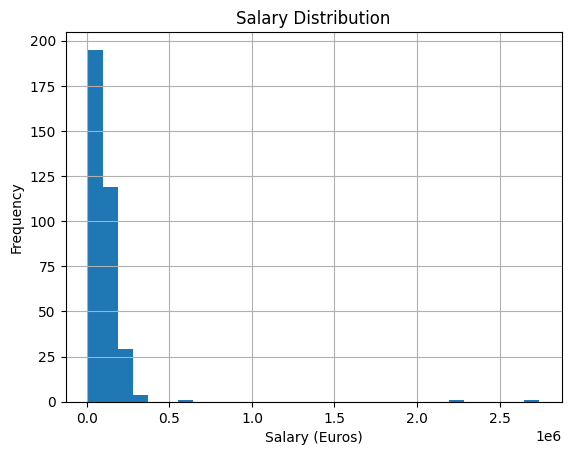

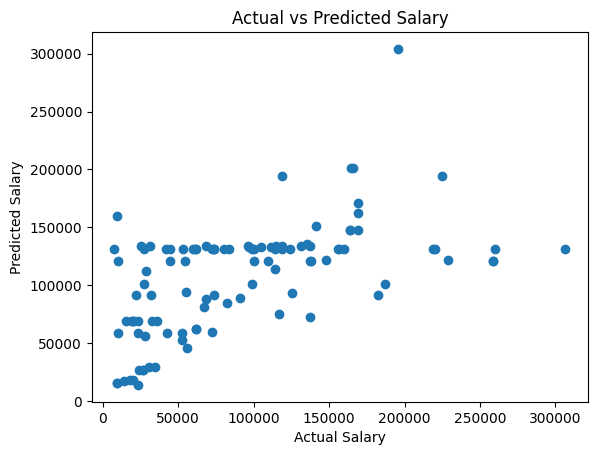

In [20]:
# 14. Final visualizations.

# Salary Distribution
y.hist(bins=30)
plt.title('Salary Distribution')
plt.xlabel('Salary (Euros)')
plt.ylabel('Frequency')
plt.show()

# Actual vs Predicted Salary
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary')
plt.show()



In [21]:
# LOGISTIC REGRESSION. Prediction seniority Level

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [23]:
display(df)

,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills,salary_numeric
0,data scientist,senior,hybrid,company_003,"Grapevine, TX . Hybrid",17 days ago,"Bentonville, AR, US",Retail,Public,€352.44B,Public,"€100,472 - €200,938","['spark', 'r', 'python', 'scala', 'machine lea...",NaN
1,data scientist,lead,hybrid,company_005,"Fort Worth, TX . Hybrid",15 days ago,"Detroit, MI, US",Manufacturing,Public,"155,030",€51.10B,"€118,733","['spark', 'r', 'python', 'sql', 'machine learn...",118733.0
2,data scientist,senior,on-site,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",a month ago,"Redwood City, CA, US",Technology,Public,"25,930",€33.80B,"€94,987 - €159,559","['aws', 'git', 'python', 'docker', 'sql', 'mac...",NaN
3,data scientist,senior,hybrid,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",8 days ago,"San Jose, CA, US",Technology,Public,"34,690",€81.71B,"€112,797 - €194,402","['sql', 'r', 'python']",NaN
4,data scientist,Unknown,on-site,company_009,On-site,3 days ago,"Stamford, CT, US",Finance,Private,"1,800",Private,"€114,172 - €228,337",[],NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,data scientist,senior,NaN,company_171,"Bengaluru, Karnataka, India",a day ago,"Armonk, NY, US",Technology,Public,"524,598",€120.29B,"€33,288 - €53,080","['pytorch', 'python', 'sql', 'machine learning...",NaN
940,machine learning engineer,senior,NaN,company_134,"Melbourne, Victoria, Australia",a month ago,"Seattle, WA, US",Retail,Public,"865,456",€838.78B,"€64,290","['amazon', 'machine learning']",64290.0
941,data scientist,midlevel,on-site,company_395,"McLean, VA",11 days ago,"McLean, VA, US",Retail,Public,"55,150",€36.29B,"€145,904 - €166,510","['spark', 'aws', 'r', 'python', 'scala', 'sql'...",NaN
942,data scientist,midlevel,on-site,company_395,"New York, NY",17 days ago,"McLean, VA, US",Retail,Public,"55,110",€36.34B,"€159,149 - €181,595","['spark', 'aws', 'r', 'python', 'scala', 'sql'...",NaN


In [24]:
# Encoding Values.

y1 = df['seniority_level'].fillna('Unknown')      # Filling missing values.
X1 = pd.get_dummies(df[['location', 'company_size']], drop_first=True)

In [25]:
y1

0        senior
1          lead
2        senior
3        senior
4       Unknown
         ...   
939      senior
940      senior
941    midlevel
942    midlevel
943      senior
Name: seniority_level, Length: 944, dtype: object

In [26]:
le = LabelEncoder()
y_encoded = le.fit_transform(y1)

In [27]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y_encoded, test_size=0.3, random_state=42)

In [28]:
model = LogisticRegression(max_iter=1000)
model.fit(X1_train, y1_train)
y1_pred = model.predict(X1_test)

In [29]:
print("Accuracy:", accuracy_score(y1_test, y1_pred))
print("Classification Report:\n", classification_report(y1_test, y1_pred, target_names=le.classes_))

Accuracy: 0.6830985915492958
Classification Report:
               precision    recall  f1-score   support

     Unknown       0.43      0.18      0.25        17
      junior       0.00      0.00      0.00         6
        lead       0.33      0.03      0.05        37
    midlevel       0.57      0.12      0.21        32
      senior       0.70      0.97      0.81       192

    accuracy                           0.68       284
   macro avg       0.41      0.26      0.26       284
weighted avg       0.60      0.68      0.59       284



C:\Users\shree\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shree\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shree\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

In [30]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X1_train, y1_train)

# Predict on the test set
y1_pred_rf = rf_model.predict(X1_test)

# Evaluate the model
print("Random Forest Classifier Performance:")
print("Accuracy:", accuracy_score(y1_test, y1_pred_rf))
print("Classification Report:\n", classification_report(y1_test, y1_pred_rf, target_names=le.classes_))

Random Forest Classifier Performance:
Accuracy: 0.6725352112676056
Classification Report:
               precision    recall  f1-score   support

     Unknown       0.43      0.18      0.25        17
      junior       0.00      0.00      0.00         6
        lead       0.33      0.08      0.13        37
    midlevel       0.56      0.16      0.24        32
      senior       0.70      0.94      0.80       192

    accuracy                           0.67       284
   macro avg       0.40      0.27      0.28       284
weighted avg       0.60      0.67      0.60       284



# Task
Improve the performance of the RandomForestClassifier model by applying SMOTE to balance the training data and then retraining and evaluating the model.

In [31]:
%pip install imblearn

Note: you may need to restart the kernel to use updated packages.



**Balance the training dataset using SMOTE.**


In [32]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X1_train = X1_train.astype(float) # Convert boolean features to float
X1_train_resampled, y1_train_resampled = smote.fit_resample(X1_train, y1_train)

print("Original training data shape:", X1_train.shape, y1_train.shape)
print("Resampled training data shape:", X1_train_resampled.shape, y1_train_resampled.shape)

Original training data shape: (660, 940) (660,)
Resampled training data shape: (2190, 940) (2190,)


In [33]:
X1_train = X1_train.astype(float)

smote = SMOTE(random_state=42)
X1_train_resampled, y1_train_resampled = smote.fit_resample(X1_train, y1_train)

print("Original training data shape:", X1_train.shape, y1_train.shape)
print("Resampled training data shape:", X1_train_resampled.shape, y1_train_resampled.shape)

Original training data shape: (660, 940) (660,)
Resampled training data shape: (2190, 940) (2190,)


**Reasoning**:
Train the RandomForestClassifier on the resampled training data.



In [34]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X1_train_resampled, y1_train_resampled)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Evaluating the model preformance using classification report.

In [35]:
y1_pred_rf = rf_model.predict(X1_test)
print("Random Forest Classifier Performance:")
print("Accuracy:", accuracy_score(y1_test, y1_pred_rf))
print("Classification Report:\n", classification_report(y1_test, y1_pred_rf, target_names=le.classes_))

Random Forest Classifier Performance:
Accuracy: 0.6619718309859155
Classification Report:
               precision    recall  f1-score   support

     Unknown       0.56      0.29      0.38        17
      junior       0.00      0.00      0.00         6
        lead       0.25      0.05      0.09        37
    midlevel       0.38      0.16      0.22        32
      senior       0.70      0.92      0.79       192

    accuracy                           0.66       284
   macro avg       0.38      0.28      0.30       284
weighted avg       0.58      0.66      0.59       284



**Reasoning**:
Define the parameter grid for GridSearchCV.



In [36]:
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

## Perform GridsearchCV ##
Use GridSearchCV to find the best hyperparameters for the RandomForestClassifier using the resampled training data.


In [37]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5)
grid_search.fit(X1_train_resampled, y1_train_resampled)

print("Best parameters found: ", grid_search.best_params_)

Best parameters found:  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}


## Evaluating the tuned model



In [38]:
best_rf_model = grid_search.best_estimator_
y1_pred_best_rf = best_rf_model.predict(X1_test)

print("Random Forest Classifier Performance with Best Parameters:")
print("Accuracy:", accuracy_score(y1_test, y1_pred_best_rf))
print("Classification Report:\n", classification_report(y1_test, y1_pred_best_rf, target_names=le.classes_))

Random Forest Classifier Performance with Best Parameters:
Accuracy: 0.6654929577464789
Classification Report:
               precision    recall  f1-score   support

     Unknown       0.56      0.29      0.38        17
      junior       0.00      0.00      0.00         6
        lead       0.29      0.05      0.09        37
    midlevel       0.38      0.16      0.22        32
      senior       0.70      0.92      0.79       192

    accuracy                           0.67       284
   macro avg       0.38      0.29      0.30       284
weighted avg       0.58      0.67      0.60       284

